In [1]:
# =========================
# Imports & Setup
# =========================
import os
import sys
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import warnings
warnings.filterwarnings("ignore")


from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.base import BaseEstimator, RegressorMixin

sys.path.append(os.path.abspath(".."))

import seaborn as sns
import matplotlib.pyplot as plt

# === Global Style ===
sns.set_theme(
    style="whitegrid",
    palette="Blues_r"   # dark → light by default
)

# === Optional: finer control ===
ACCENT = "#1565C0"

plt.rcParams.update({
    "figure.dpi"      : 150,
    "axes.titlesize"  : 14,
    "axes.labelsize"  : 12,
    "xtick.labelsize" : 10,
    "ytick.labelsize" : 10,
    "legend.fontsize" : 10,
})


FIG_DIR = "../reports/figures"
os.makedirs(FIG_DIR, exist_ok=True)

def save_plot(name):
    plt.savefig(f"{FIG_DIR}/{name}.png", bbox_inches="tight", dpi=300)

In [2]:
# =========================
# FLAML Wrapper for Loading
# =========================
class FLAMLRegressorWrapper(BaseEstimator, RegressorMixin):

    def __init__(
        self,
        time_budget=120,
        metric="rmse",
        estimator_list=None,
        seed=42,
        n_jobs=-1,
        task="regression",
        log_file_name="flaml.log",
        eval_method="cv",
        n_splits=3,
        split_ratio=None,
    ):
        self.time_budget = time_budget
        self.metric = metric
        self.estimator_list = estimator_list
        self.seed = seed
        self.n_jobs = n_jobs
        self.task = task
        self.log_file_name = log_file_name
        self.eval_method = eval_method
        self.n_splits = n_splits
        self.split_ratio = split_ratio
        self.automl_ = None

    def fit(self, X, y):
        raise NotImplementedError("Used only for loading.")

    def predict(self, X):
        return self.automl_.predict(X)

In [3]:
# =========================
# Load Model + Metadata
# =========================
model_pipeline = joblib.load("../models/model_validation.pkl")

with open("../models/model_metadata.json", "r") as f:
    metadata = json.load(f)

print("=== MODEL INFO ===")
print("Best model:", metadata["best_model_name"])
print("Model type:", metadata["best_model_type"])
print("Family:", metadata["best_model_family"])

=== MODEL INFO ===
Best model: FLAML AutoML
Model type: sklearn
Family: automl_flaml


In [4]:
# =========================
# Load Cleaned Data
# =========================
from src.data_preprocessing import load_clean_data

df = load_clean_data("../data/processed/cleaned_delivery_data.csv")

target = metadata["target"]

X = df.drop(columns=[target])
y = df[target]

drop_cols = ["order_id", "driver_id", "order_date", "order_time", "pickup_time"]
X = X.drop(columns=[col for col in drop_cols if col in X.columns])

# Ensure exact same feature set used during training
X = X[metadata["selected_features_used"]]

print("Dataset shape:", df.shape)
print("Feature matrix shape:", X.shape)
print("Target:", target)
print("Selected features:", list(X.columns))

Dataset shape: (45082, 25)
Feature matrix shape: (45082, 15)
Target: delivery_time_min
Selected features: ['driver_age', 'driver_rating', 'weather', 'traffic_density', 'vehicle_condition', 'order_type', 'vehicle_type', 'num_deliveries', 'is_festival', 'city', 'distance_km', 'order_hour', 'order_day', 'is_weekend', 'is_peak_hour']


In [5]:
# =========================
# Same Validation Split
# =========================
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)

Train shape: (36065, 15)
Validation shape: (9017, 15)


In [6]:
print(model_pipeline)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(force_int_remainder_cols='deprecated',
                                   transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['driver_age',
                                                   'driver_rating',
                                                   'vehicle_condition',
                                                   'num_deliveries',
                                                   'distance_km', 'order_hour',
                                                   'is_weekend',
                                                   'is_peak_hour']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                               

In [7]:
# =========================
# Evaluate Full Pipeline
# =========================
val_preds = model_pipeline.predict(X_val)

print("\n=== VALIDATION METRICS (full pipeline) ===")
print("Validation MAE:", mean_absolute_error(y_val, val_preds))
print("Validation RMSE:", np.sqrt(mean_squared_error(y_val, val_preds)))
print("Validation R2:", r2_score(y_val, val_preds))


=== VALIDATION METRICS (full pipeline) ===
Validation MAE: 3.0477273838465972
Validation RMSE: 3.7907659910314733
Validation R2: 0.8363471034362416


In [8]:
# =========================
# Extract Pipeline Parts
# =========================
preprocessor = model_pipeline.named_steps["preprocessor"]
model = model_pipeline.named_steps["model"]

feature_names = preprocessor.get_feature_names_out()
print("\nTransformed feature count:", len(feature_names))


Transformed feature count: 38


In [9]:
# =========================
# Transform Validation Data
# =========================
X_val_transformed = preprocessor.transform(X_val)

X_val_transformed = pd.DataFrame(
    X_val_transformed,
    columns=feature_names,
    index=X_val.index
)

print("Transformed validation shape:", X_val_transformed.shape)

Transformed validation shape: (9017, 38)


In [10]:
# =========================
# Unwrap Underlying Model if Needed
# =========================
raw_model = model

# Case 1: model has .automl_ (custom wrapper storing FLAML object)
if hasattr(raw_model, "automl_") and raw_model.automl_ is not None:
    print("Detected FLAML wrapper via .automl_")
    raw_model = raw_model.automl_.model

# Case 2: model has .model (FLAML selected estimator or wrapped estimator)
if hasattr(raw_model, "model"):
    print("Extracting underlying estimator via .model")
    raw_model = raw_model.model

print("Final estimator used for SHAP / feature importance:", type(raw_model))

Detected FLAML wrapper via .automl_
Extracting underlying estimator via .model
Final estimator used for SHAP / feature importance: <class 'sklearn.ensemble._forest.RandomForestRegressor'>


In [11]:
# =========================
# Manual Prediction Check
# =========================
manual_val_preds = raw_model.predict(X_val_transformed)

print("\n=== VALIDATION METRICS (manual transformed data) ===")
print("Validation MAE:", mean_absolute_error(y_val, manual_val_preds))
print("Validation RMSE:", np.sqrt(mean_squared_error(y_val, manual_val_preds)))
print("Validation R2:", r2_score(y_val, manual_val_preds))


=== VALIDATION METRICS (manual transformed data) ===
Validation MAE: 3.0477273838465972
Validation RMSE: 3.7907659910314733
Validation R2: 0.8363471034362416


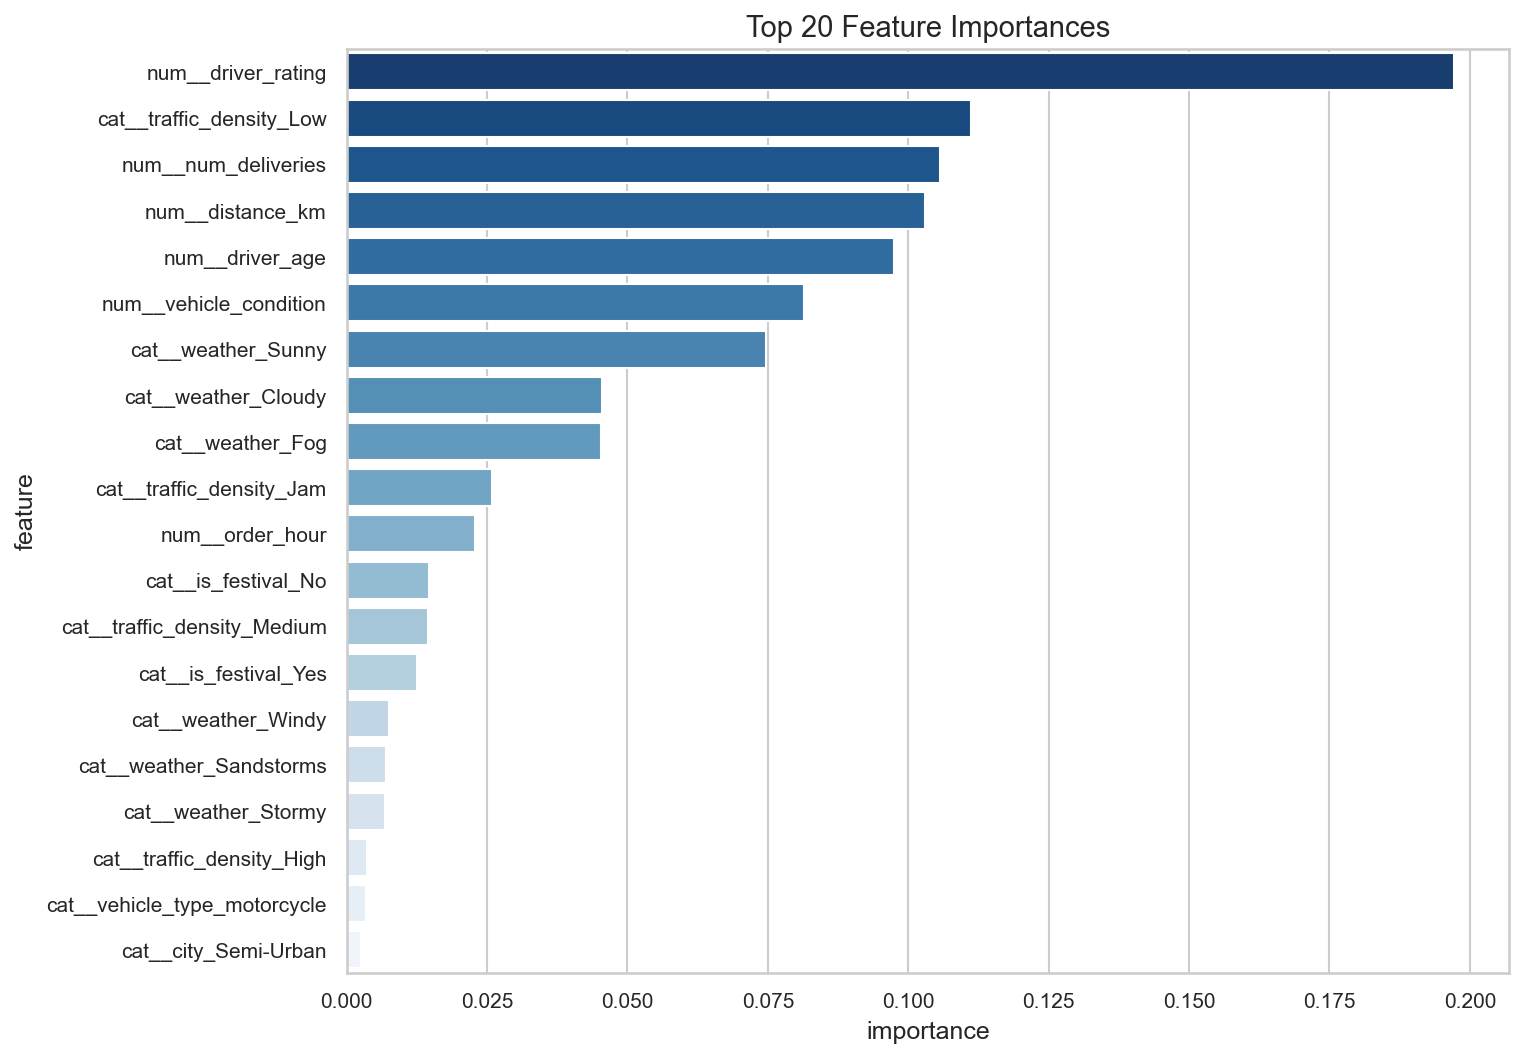


Top 20 Features by Built-in Importance:
                         feature  importance
1             num__driver_rating    0.197137
16      cat__traffic_density_Low    0.111132
3            num__num_deliveries    0.105657
4               num__distance_km    0.103002
0                num__driver_age    0.097462
2         num__vehicle_condition    0.081441
12            cat__weather_Sunny    0.074628
8            cat__weather_Cloudy    0.045536
9               cat__weather_Fog    0.045367
15      cat__traffic_density_Jam    0.025952
5                num__order_hour    0.022823
26           cat__is_festival_No    0.014598
17   cat__traffic_density_Medium    0.014450
27          cat__is_festival_Yes    0.012582
13            cat__weather_Windy    0.007478
10       cat__weather_Sandstorms    0.006937
11           cat__weather_Stormy    0.006918
14     cat__traffic_density_High    0.003624
24  cat__vehicle_type_motorcycle    0.003372
29          cat__city_Semi-Urban    0.002572


In [12]:
# =========================
# Built-in Feature Importances
# =========================
importance_df = None

if hasattr(raw_model, "feature_importances_"):
    importance_df = pd.DataFrame({
        "feature": feature_names,
        "importance": raw_model.feature_importances_
    }).sort_values(by="importance", ascending=False)

    top_n = importance_df.head(20)

    # Create gradient palette (light → dark blue)
    palette = sns.color_palette("Blues_r", n_colors=len(top_n))

    plt.figure(figsize=(10, 8))
    sns.barplot(
        data=top_n,
        x="importance",
        y="feature",
        palette=palette
    )

    plt.title("Top 20 Feature Importances")
    save_plot("feature_importance")
    plt.show()

    print("\nTop 20 Features by Built-in Importance:")
    print(top_n)

else:
    print("Model does not expose feature_importances_.")

In [13]:
# =========================
# SHAP on Sample (faster)
# =========================
# Use up to 5000 validation rows for SHAP
X_val_shap = X_val.iloc[:5000].copy()
X_val_shap_transformed = preprocessor.transform(X_val_shap)

X_val_shap_transformed = pd.DataFrame(
    X_val_shap_transformed,
    columns=feature_names,
    index=X_val_shap.index
)

try:
    explainer = shap.TreeExplainer(raw_model)
    print("\nUsing TreeExplainer")
except Exception:
    explainer = shap.Explainer(raw_model.predict, X_val_shap_transformed)
    print("\nUsing Generic Explainer")

shap_values = explainer(X_val_shap_transformed)

print("SHAP shape:", shap_values.values.shape)
print("Base value:", shap_values.base_values[0])


Using TreeExplainer
SHAP shape: (5000, 38)
Base value: 26.336869432370204


In [34]:
# =========================
# SINGLE PREDICTION DEEP-DIVE
# =========================
def analyze_single_case(idx=0):
    """
    Deep analysis of a single prediction:
    - Actual vs Predicted
    - Error breakdown
    - SHAP explanation (local)
    - Context (distance, traffic, etc.)
    """

    if idx >= len(X_val):
        print("Index out of range")
        return

    print("\n" + "="*50)
    print(f"🔍 SINGLE CASE ANALYSIS (Index = {idx})")
    print("="*50)

    # --- Get original index ---
    original_idx = X_val.index[idx]

    # --- Actual vs Predicted ---
    actual = y_val.loc[original_idx]
    predicted = val_preds[idx]
    error = actual - predicted
    abs_error = abs(error)

    print("\n📊 Prediction vs Actual")
    print(f"Actual Delivery Time   : {actual:.2f}")
    print(f"Predicted Delivery Time: {predicted:.2f}")
    print(f"Error (Actual - Pred)  : {error:.2f}")
    print(f"Absolute Error         : {abs_error:.2f}")

    # --- Relative context ---
    print("\n📈 Error Context")
    print(f"Mean Absolute Error (overall): {df_val['abs_error'].mean():.2f}")
    print(f"This case is {'HIGH' if abs_error > df_val['abs_error'].mean() else 'LOW'} error")

    # --- Show raw feature values ---
    print("\n📦 Raw Input Features (original space)")
    print(X_val.loc[original_idx])

    # --- SHAP LOCAL EXPLANATION ---
    print("\n🧠 SHAP Local Explanation")

    row_shap = shap_values[idx]

    shap_df = pd.DataFrame({
        "feature": X_val_shap_transformed.columns,
        "shap_value": row_shap.values,
        "abs_shap": np.abs(row_shap.values)
    }).sort_values("abs_shap", ascending=False)

    print("\nTop 10 contributing features:")
    print(shap_df.head(10))

    # --- Natural language explanation ---
    positives = shap_df[shap_df["shap_value"] > 0].head(5)
    negatives = shap_df[shap_df["shap_value"] < 0].head(5)

    if not positives.empty:
        pos_text = ", ".join(
            [f"{row.feature} (+{row.shap_value:.2f})" for row in positives.itertuples()]
        )
        print(f"\n⬆️ Increased prediction due to: {pos_text}")

    if not negatives.empty:
        neg_text = ", ".join(
            [f"{row.feature} ({row.shap_value:.2f})" for row in negatives.itertuples()]
        )
        print(f"\n⬇️ Decreased prediction due to: {neg_text}")

    # --- Waterfall plot ---
    try:
        shap.plots.waterfall(row_shap, show=False)
        save_plot(f"single_case_waterfall_{idx}")
        plt.show()
    except Exception as e:
        print("Waterfall plot failed:", e)

    # --- Compare with similar group (bias context) ---
    print("\n⚖️ Bias / Context Check")

    row = df_val.loc[original_idx]

    if "traffic_density" in df_val.columns:
        group_mae = df_val.groupby("traffic_density")["abs_error"].mean()
        print("\nTraffic group error comparison:")
        print(group_mae)
        print(f"This sample traffic: {row.get('traffic_density', 'N/A')}")

    if "weather" in df_val.columns:
        group_mae = df_val.groupby("weather")["abs_error"].mean()
        print("\nWeather group error comparison:")
        print(group_mae)
        print(f"This sample weather: {row.get('weather', 'N/A')}")

    if "distance_km" in df_val.columns:
        median_dist = df_val["distance_km"].median()
        dist_group = "Far" if row["distance_km"] >= median_dist else "Near"

        far_mae = df_val[df_val["distance_km"] >= median_dist]["abs_error"].mean()
        near_mae = df_val[df_val["distance_km"] < median_dist]["abs_error"].mean()

        print("\nDistance bias check:")
        print(f"Near MAE: {near_mae:.2f}")
        print(f"Far MAE : {far_mae:.2f}")
        print(f"This sample is: {dist_group}")

    print("\n" + "="*50)


🔍 SINGLE CASE ANALYSIS (Index = 5)

📊 Prediction vs Actual
Actual Delivery Time   : 20.00
Predicted Delivery Time: 18.42
Error (Actual - Pred)  : 1.58
Absolute Error         : 1.58

📈 Error Context
Mean Absolute Error (overall): 3.05
This case is LOW error

📦 Raw Input Features (original space)
driver_age                       20.0
driver_rating                     4.9
weather                         Sunny
traffic_density                   Low
vehicle_condition                   2
order_type                     Buffet
vehicle_type         electric_scooter
num_deliveries                      0
is_festival                        No
city                            Urban
distance_km                  3.116248
order_hour                          8
order_day                      Monday
is_weekend                          0
is_peak_hour                        0
Name: 44135, dtype: object

🧠 SHAP Local Explanation

Top 10 contributing features:
                     feature  shap_value  abs_sha

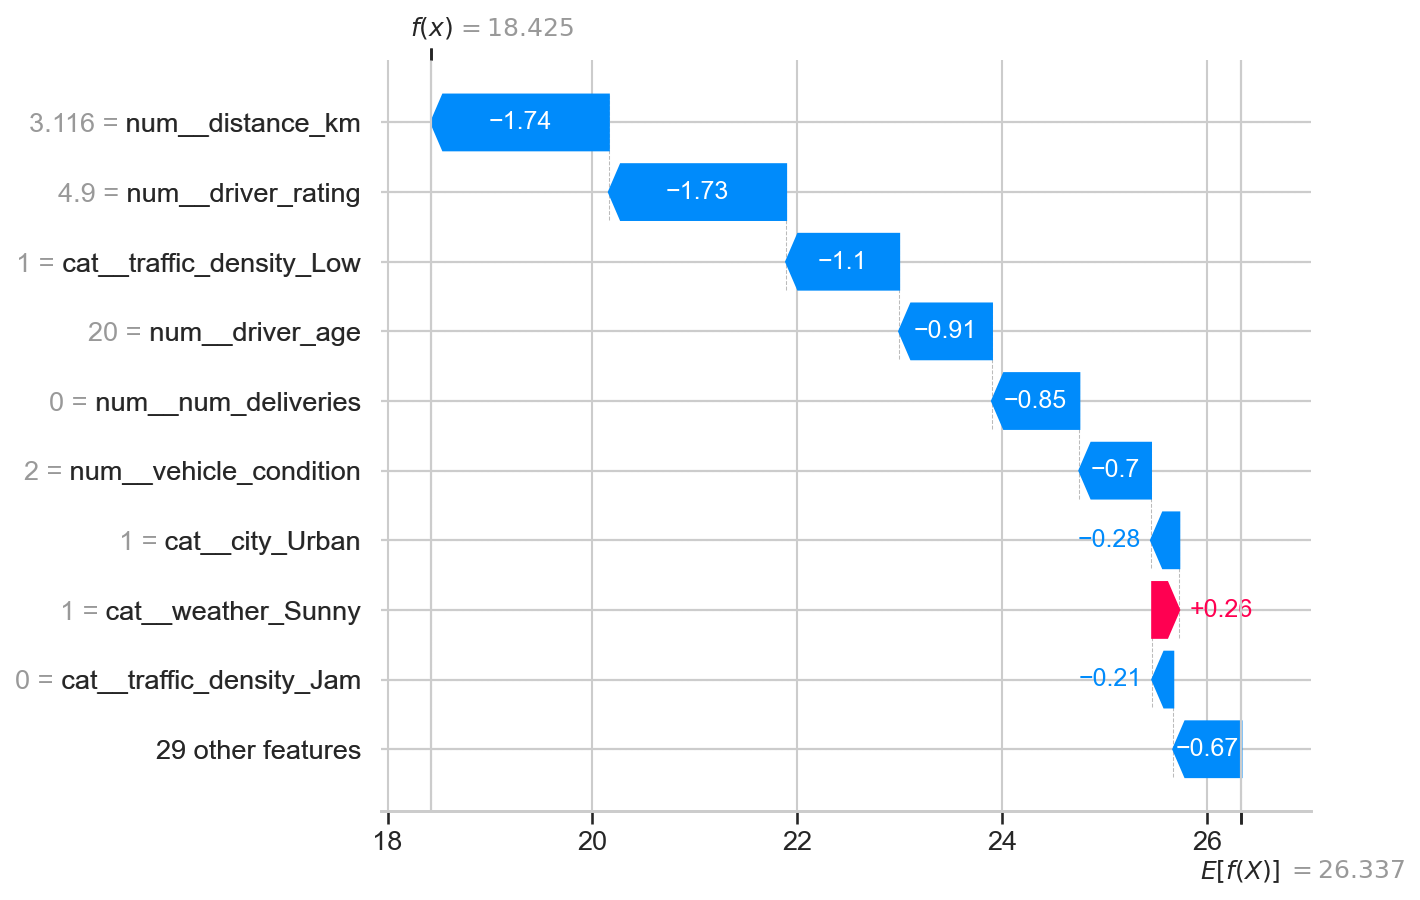


⚖️ Bias / Context Check

Traffic group error comparison:
traffic_density
High      3.115913
Jam       3.468317
Low       2.687688
Medium    3.014790
Name: abs_error, dtype: float64
This sample traffic: Low

Weather group error comparison:
weather
Cloudy        2.735720
Fog           2.880572
Sandstorms    3.203438
Stormy        3.264468
Sunny         2.935205
Windy         3.301165
Name: abs_error, dtype: float64
This sample weather: Sunny

Distance bias check:
Near MAE: 2.82
Far MAE : 3.28
This sample is: Near



In [35]:
analyze_single_case(idx=5)

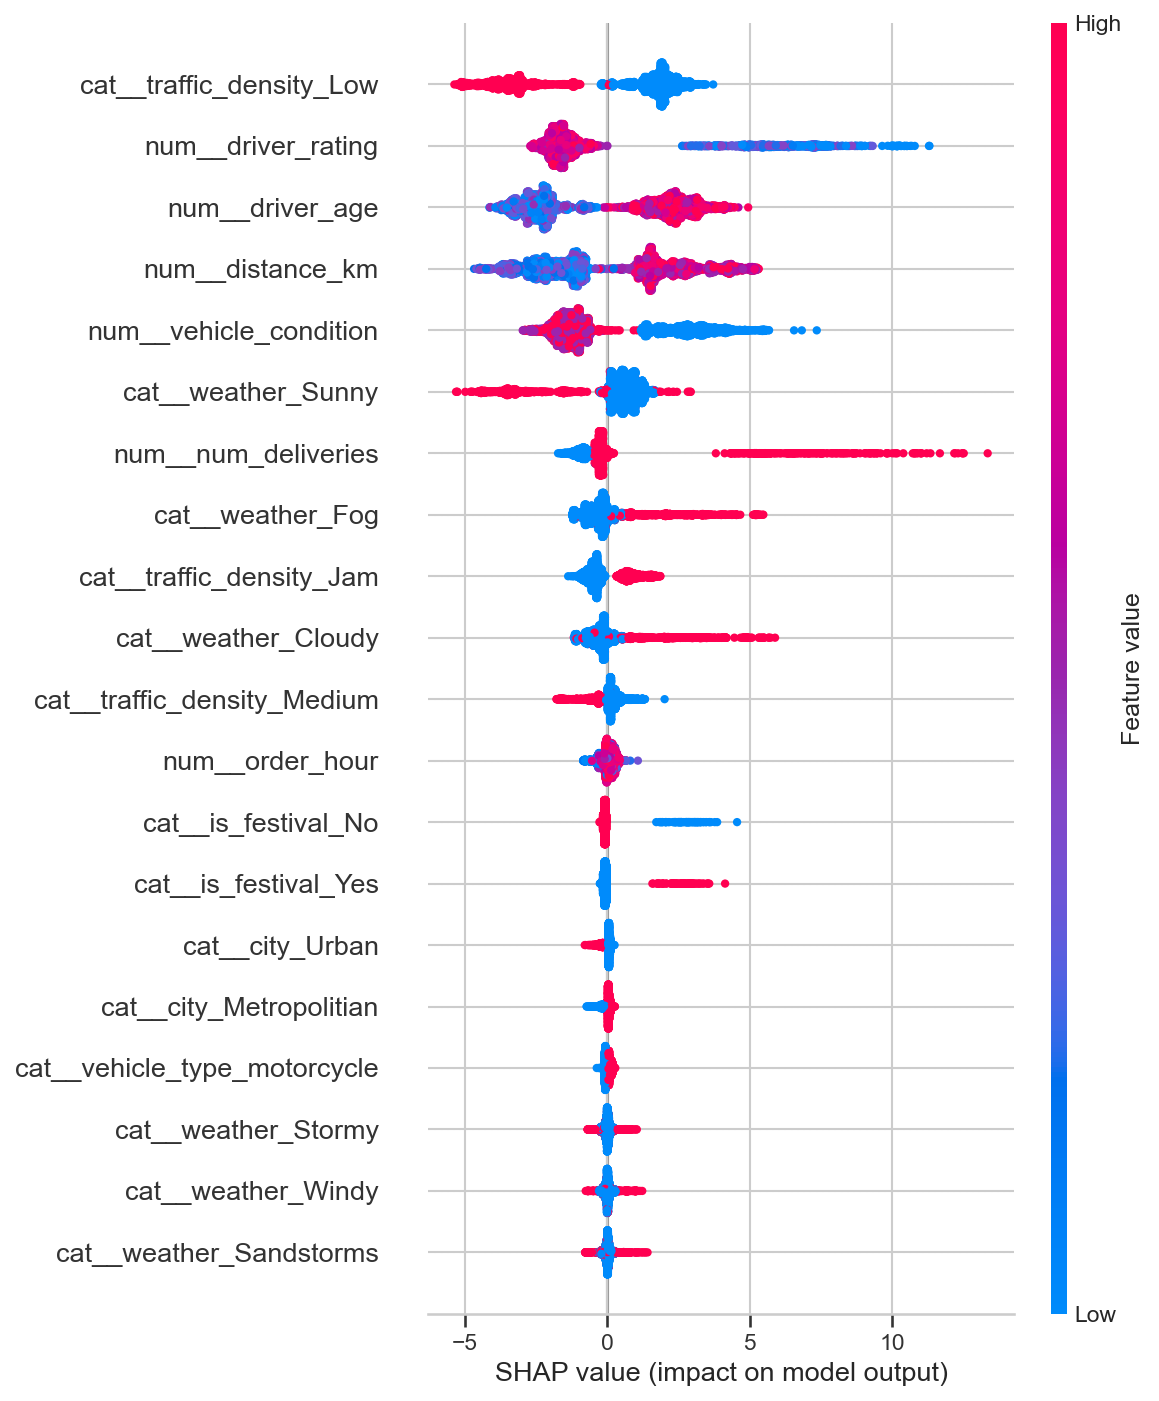

In [14]:
# =========================
# SHAP Summary Plot
# =========================
shap.summary_plot(shap_values, X_val_shap_transformed, show=False)
save_plot("shap_summary")
plt.show()

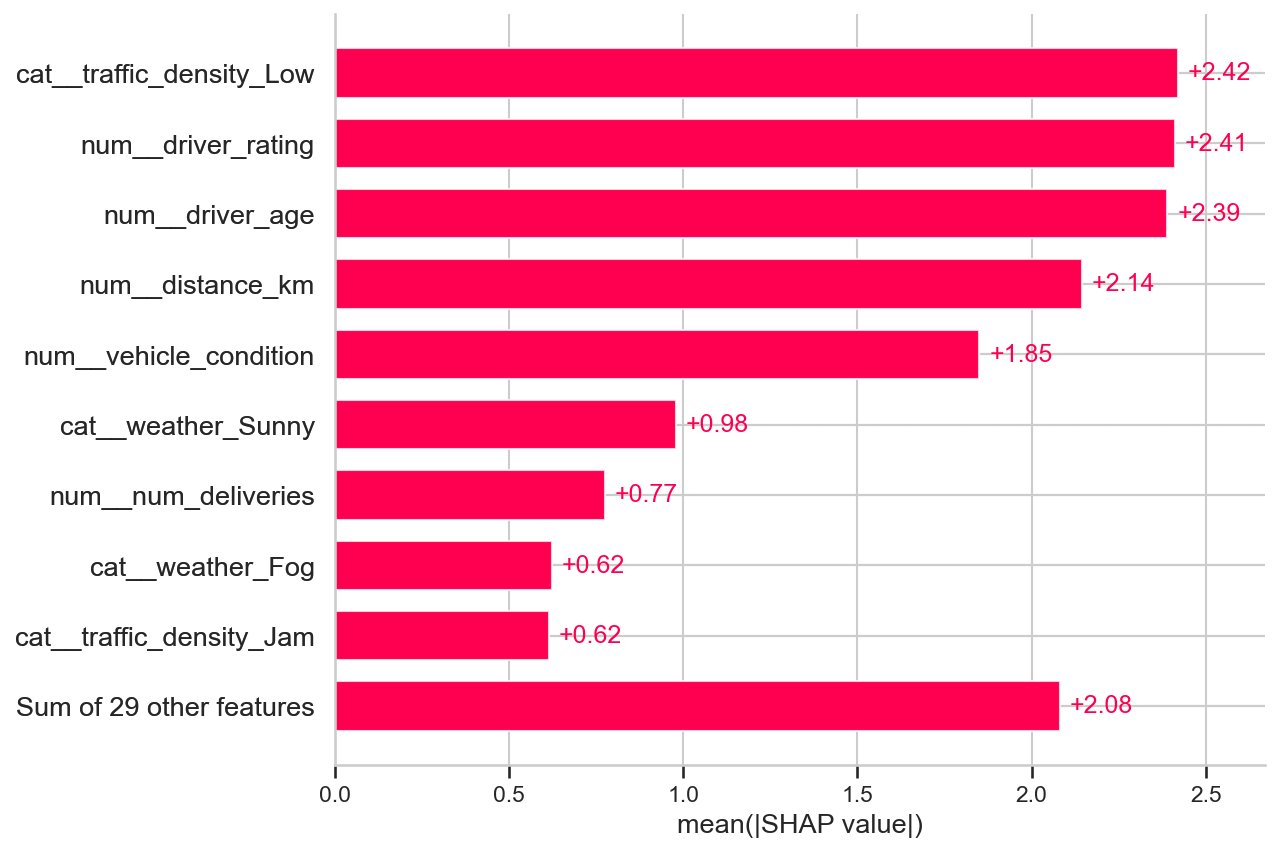

In [15]:
# =========================
# SHAP Global Bar Plot
# =========================
shap.plots.bar(shap_values, show=False)
save_plot("shap_bar")
plt.show()


In [16]:
# =========================
# SHAP Importance Table
# =========================
mean_shap = np.abs(shap_values.values).mean(axis=0)

shap_importance = pd.DataFrame({
    "feature": X_val_shap_transformed.columns,
    "mean_abs_shap": mean_shap
}).sort_values("mean_abs_shap", ascending=False)

print("\nTop 20 Features by Mean |SHAP|:")
print(shap_importance.head(20))


Top 20 Features by Mean |SHAP|:
                         feature  mean_abs_shap
16      cat__traffic_density_Low       2.420890
1             num__driver_rating       2.412203
0                num__driver_age       2.389443
4               num__distance_km       2.144566
2         num__vehicle_condition       1.849870
12            cat__weather_Sunny       0.979935
3            num__num_deliveries       0.774696
9               cat__weather_Fog       0.623236
15      cat__traffic_density_Jam       0.615645
8            cat__weather_Cloudy       0.565101
17   cat__traffic_density_Medium       0.307567
5                num__order_hour       0.174101
26           cat__is_festival_No       0.127561
27          cat__is_festival_Yes       0.120923
30               cat__city_Urban       0.105500
28       cat__city_Metropolitian       0.087881
24  cat__vehicle_type_motorcycle       0.087360
11           cat__weather_Stormy       0.086263
13            cat__weather_Windy       0.085538
10     

In [17]:
# =========================
# Compare Built-in Importances vs SHAP
# =========================
if importance_df is not None:
    compare_df = importance_df.merge(
        shap_importance,
        on="feature",
        how="inner"
    )

    print("\n=== Importance Comparison ===")
    print(compare_df.head(20))


=== Importance Comparison ===
                         feature  importance  mean_abs_shap
0             num__driver_rating    0.197137       2.412203
1       cat__traffic_density_Low    0.111132       2.420890
2            num__num_deliveries    0.105657       0.774696
3               num__distance_km    0.103002       2.144566
4                num__driver_age    0.097462       2.389443
5         num__vehicle_condition    0.081441       1.849870
6             cat__weather_Sunny    0.074628       0.979935
7            cat__weather_Cloudy    0.045536       0.565101
8               cat__weather_Fog    0.045367       0.623236
9       cat__traffic_density_Jam    0.025952       0.615645
10               num__order_hour    0.022823       0.174101
11           cat__is_festival_No    0.014598       0.127561
12   cat__traffic_density_Medium    0.014450       0.307567
13          cat__is_festival_Yes    0.012582       0.120923
14            cat__weather_Windy    0.007478       0.085538
15       

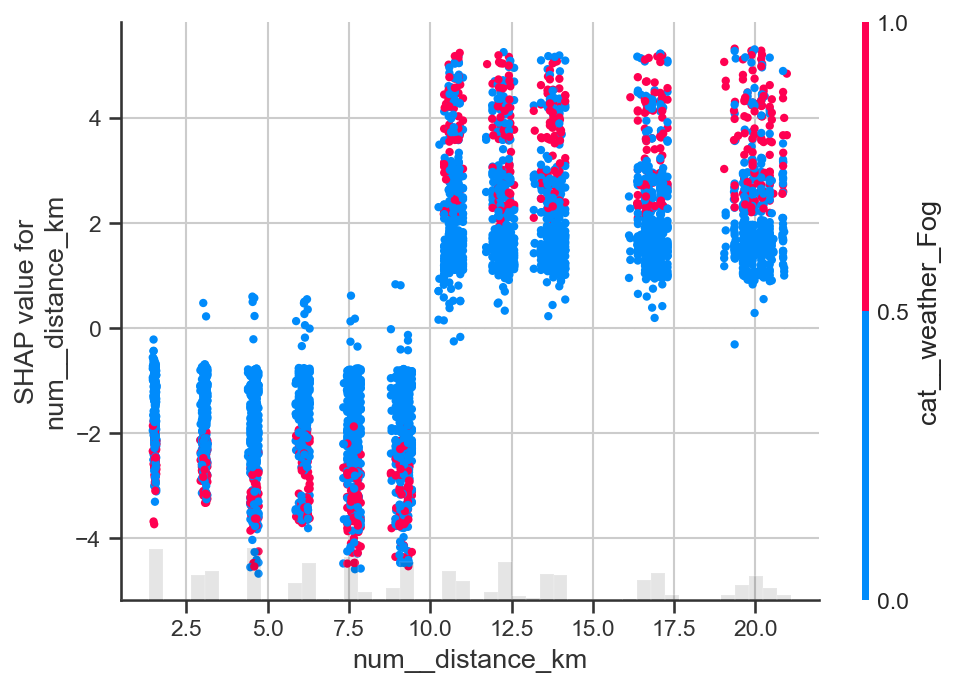

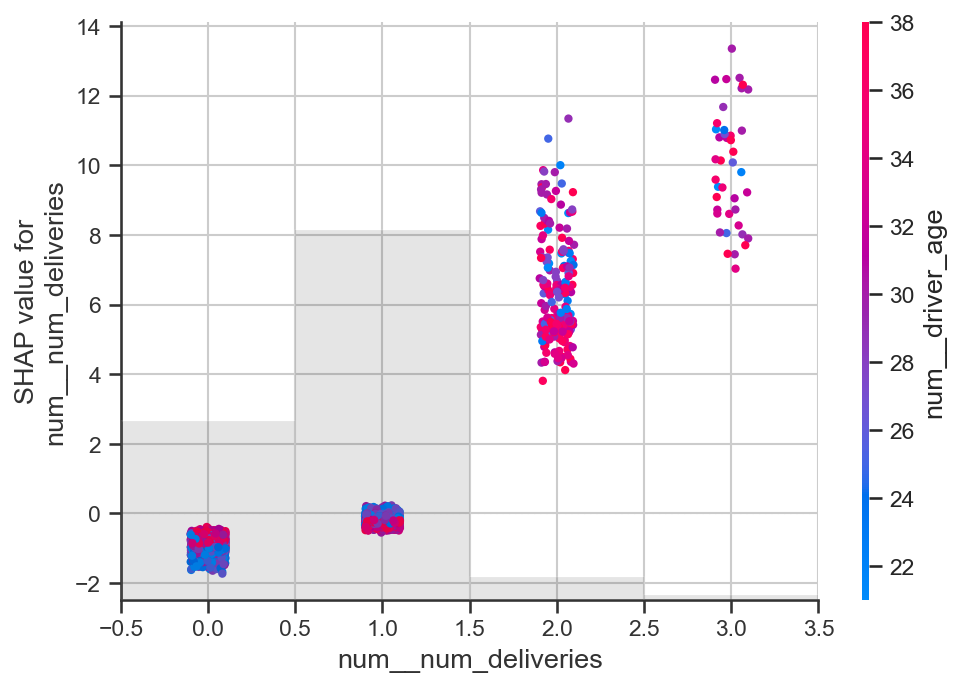

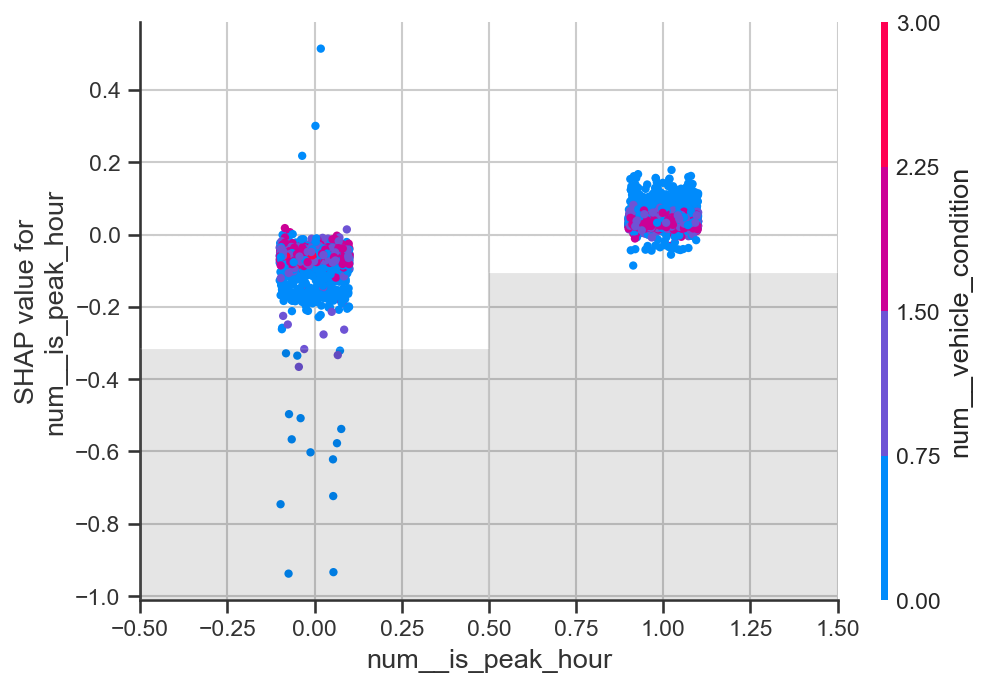

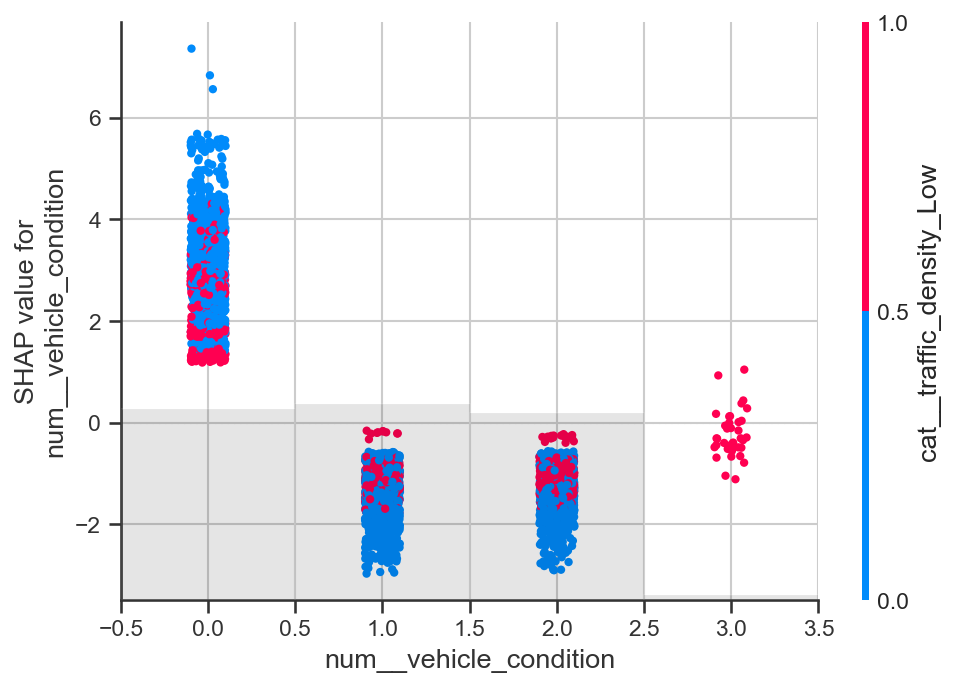

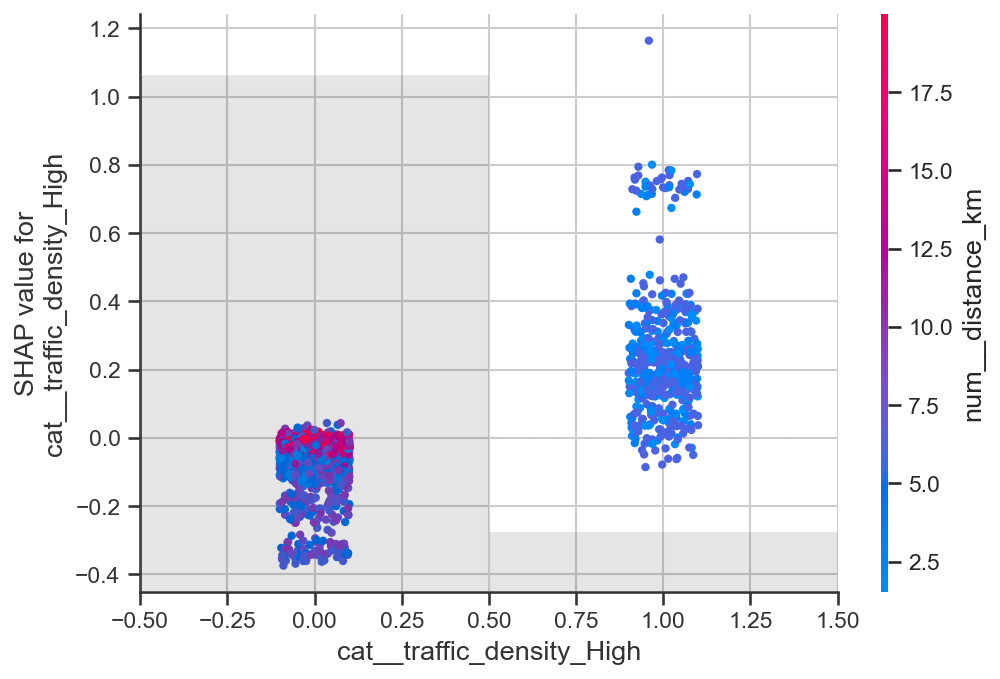

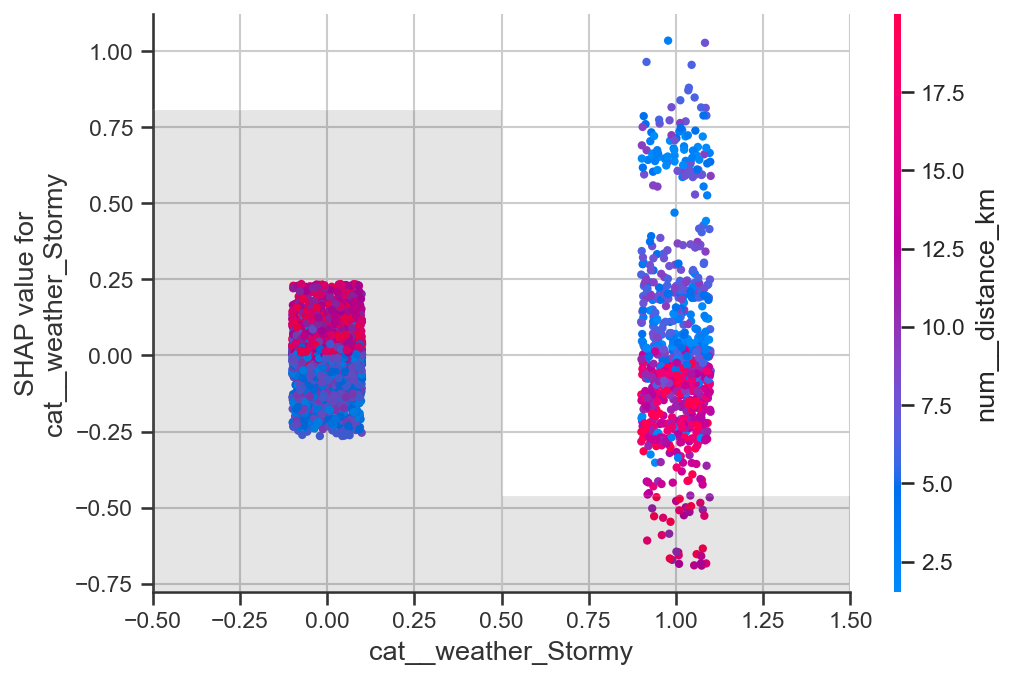

In [18]:
# =========================
# SHAP Dependence / Scatter for Key Features
# =========================
candidate_features = [
    "num__distance_km",
    "num__num_deliveries",
    "num__is_peak_hour",
    "num__vehicle_condition",
    "cat__traffic_density_High",
    "cat__weather_Stormy"
]

for feat in candidate_features:
    if feat in X_val_shap_transformed.columns:
        try:
            shap.plots.scatter(shap_values[:, feat], color=shap_values, show=False)
            save_plot(f"shap_scatter_{feat.replace('__', '_').replace('/', '_')}")
            plt.show()
        except Exception as e:
            print(f"Could not create SHAP scatter for {feat}: {e}")

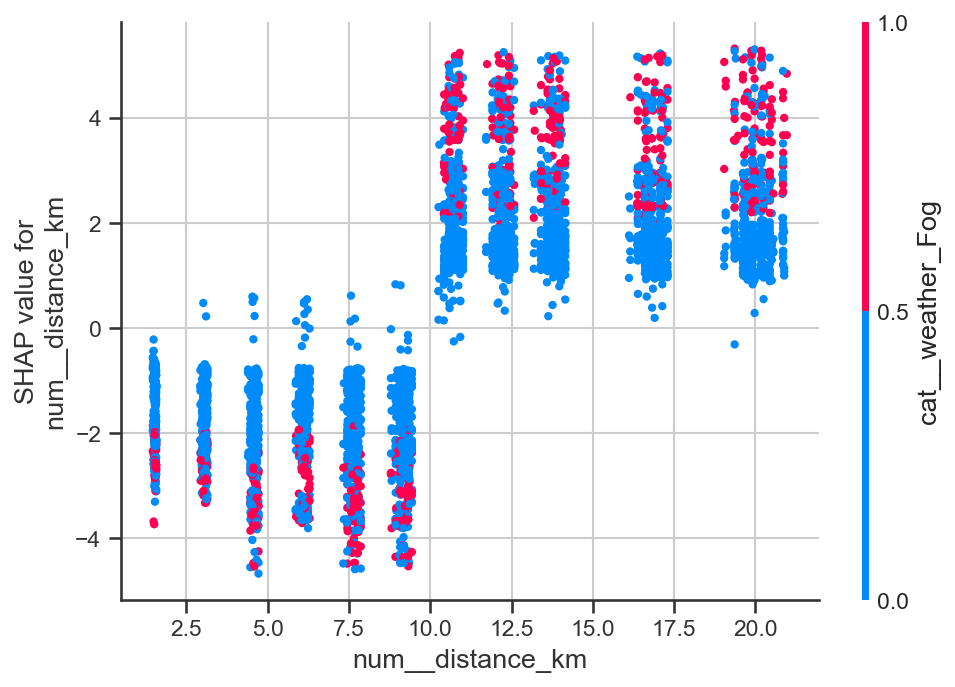

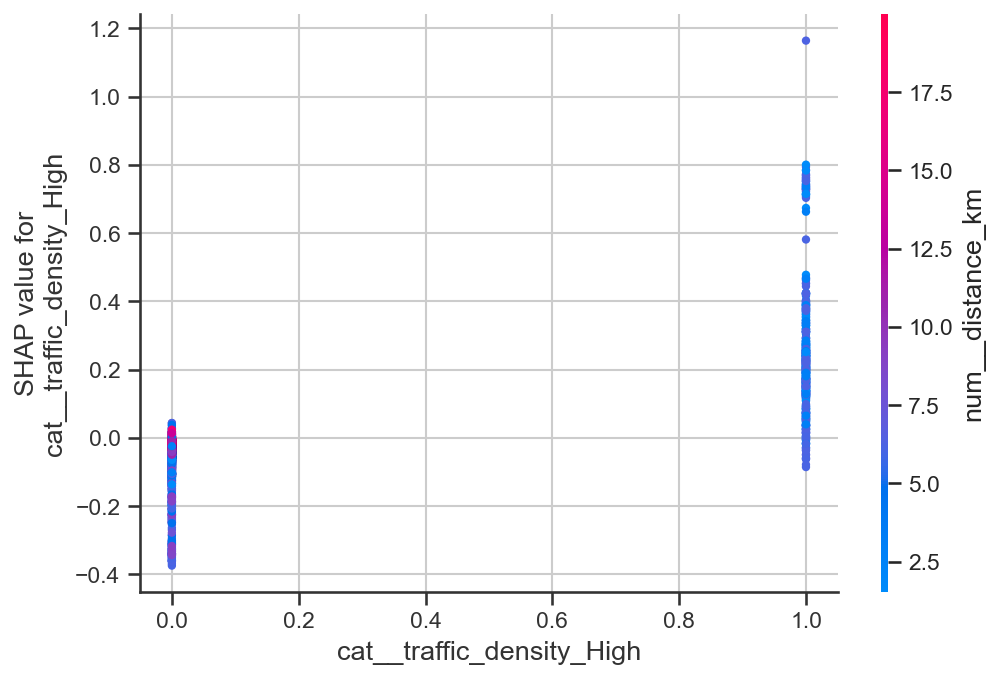

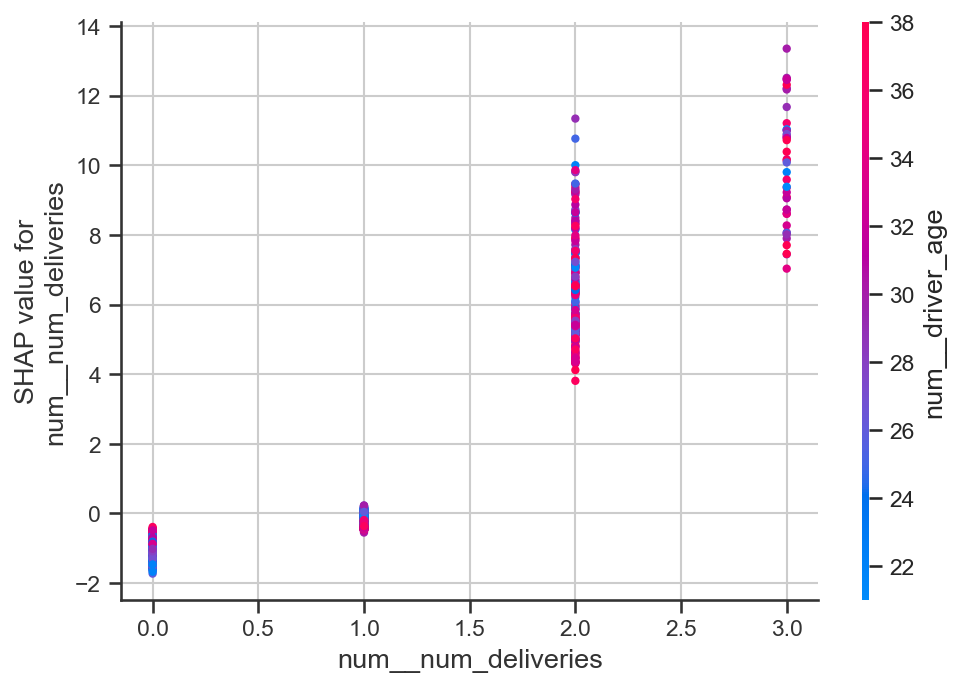

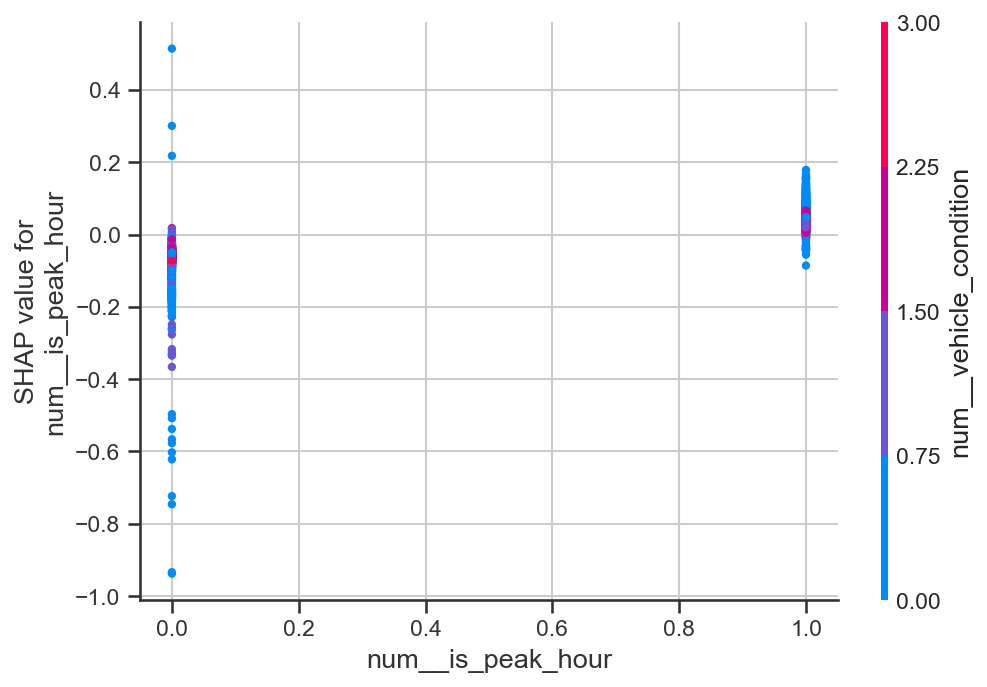

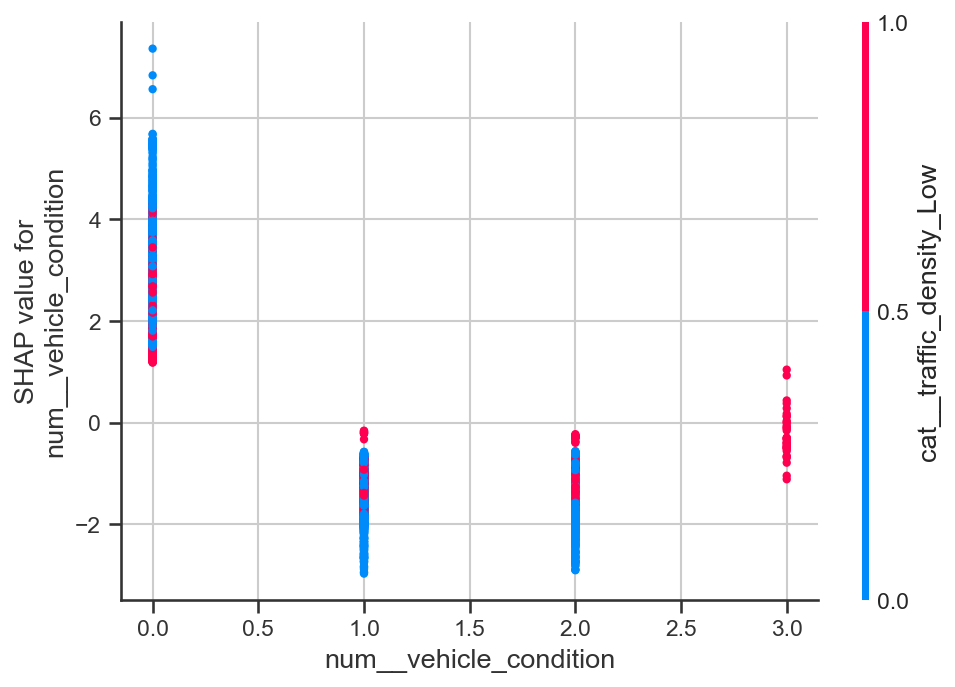

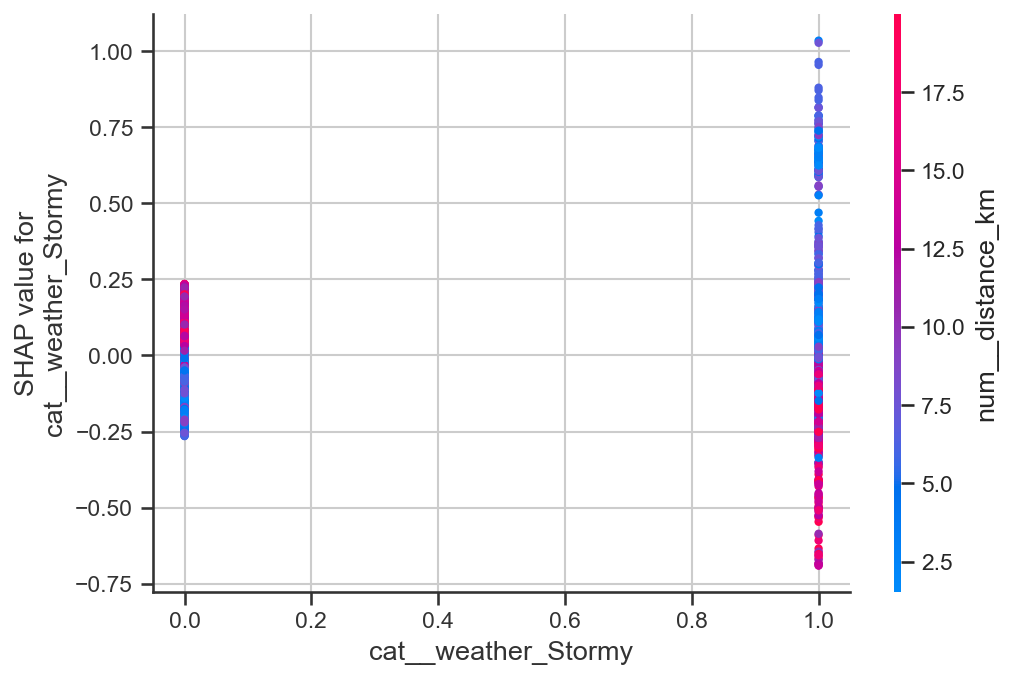

In [19]:
# =========================
# SHAP Dependence Plots
# =========================
dependence_features = [
    "num__distance_km",
    "cat__traffic_density_High",
    "num__num_deliveries",
    "num__is_peak_hour",
    "num__vehicle_condition",
    "cat__weather_Stormy"
]

for feat in dependence_features:
    if feat in X_val_shap_transformed.columns:
        try:
            shap.dependence_plot(
                feat,
                shap_values.values,
                X_val_shap_transformed,
                show=False
            )
            save_plot(f"dependence_{feat.replace('__', '_').replace('/', '_')}")
            plt.show()
        except Exception as e:
            print(f"Could not create dependence plot for {feat}: {e}")

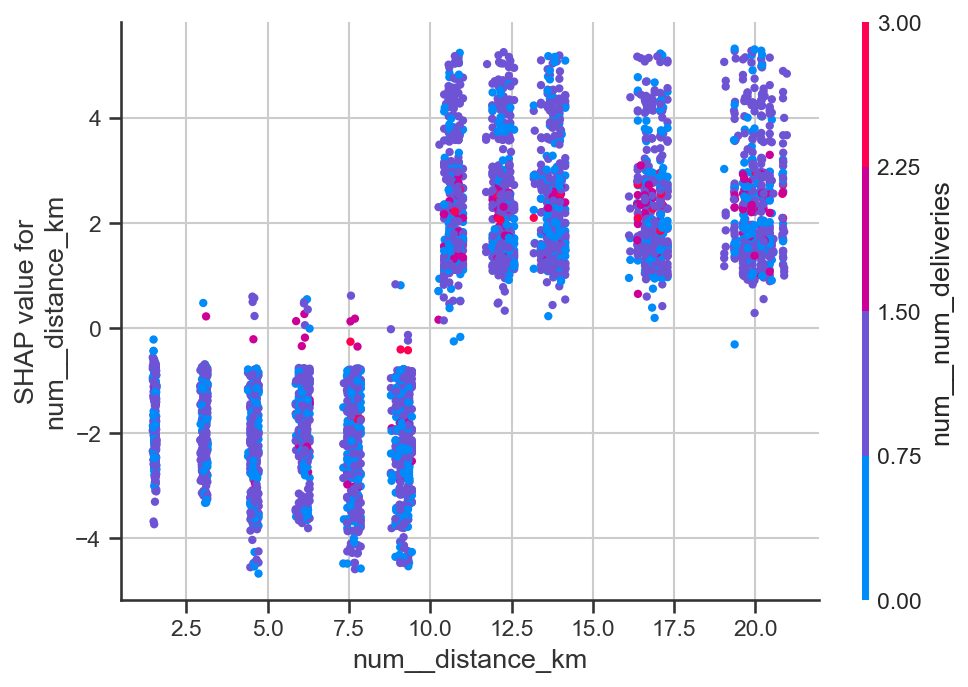

In [20]:
# =========================
# SHAP Interaction Example
# =========================
if (
    "num__distance_km" in X_val_shap_transformed.columns and
    "num__num_deliveries" in X_val_shap_transformed.columns
):
    try:
        shap.dependence_plot(
            "num__distance_km",
            shap_values.values,
            X_val_shap_transformed,
            interaction_index="num__num_deliveries",
            show=False
        )
        save_plot("dependence_distance_deliveries_interaction")
        plt.show()
    except Exception as e:
        print("Could not create interaction dependence plot:", e)

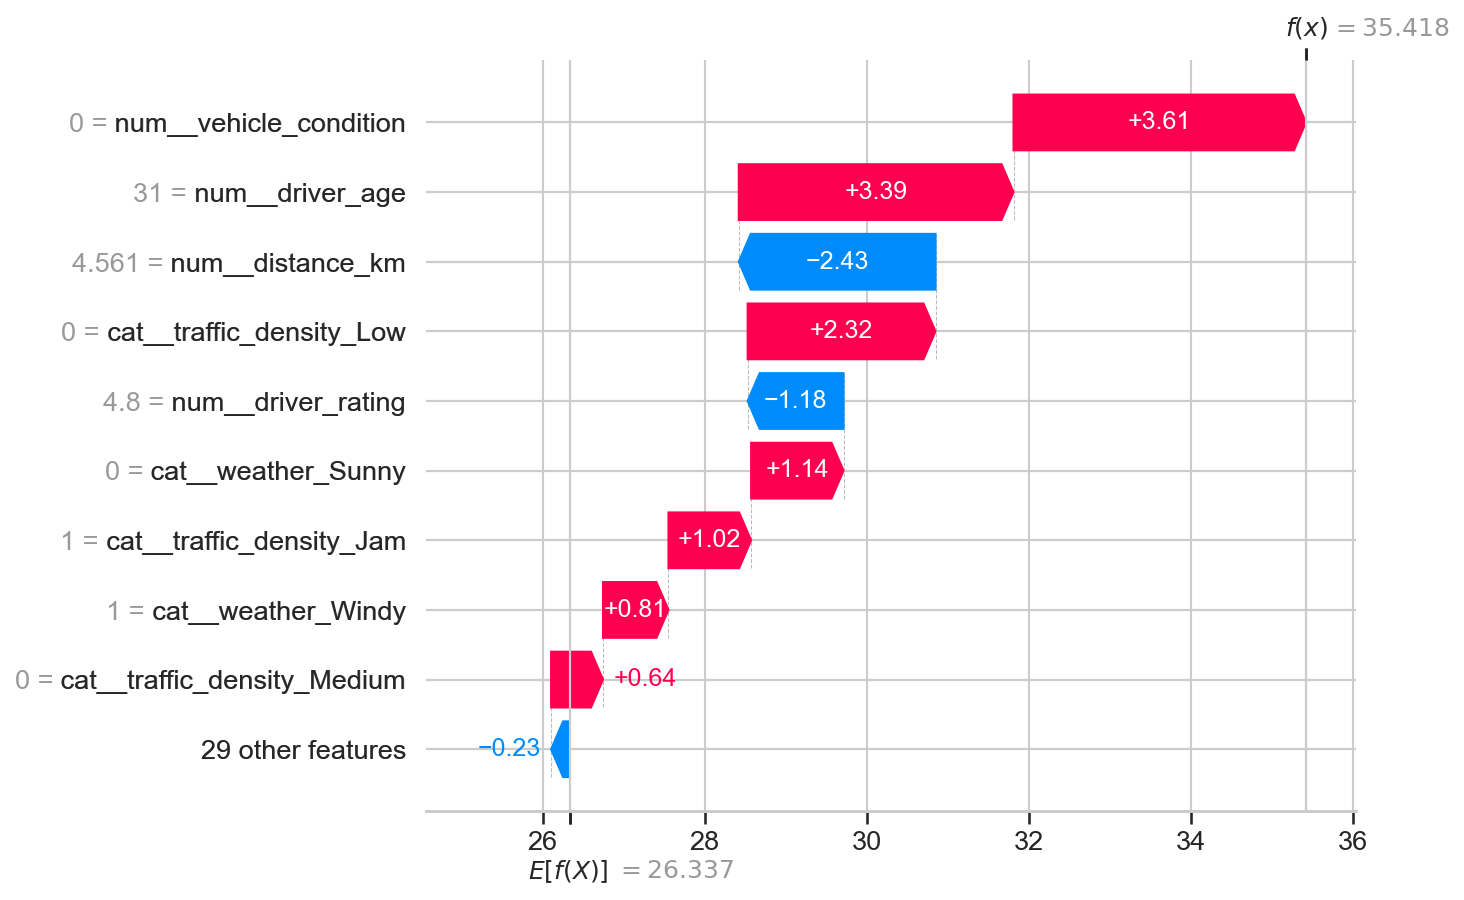

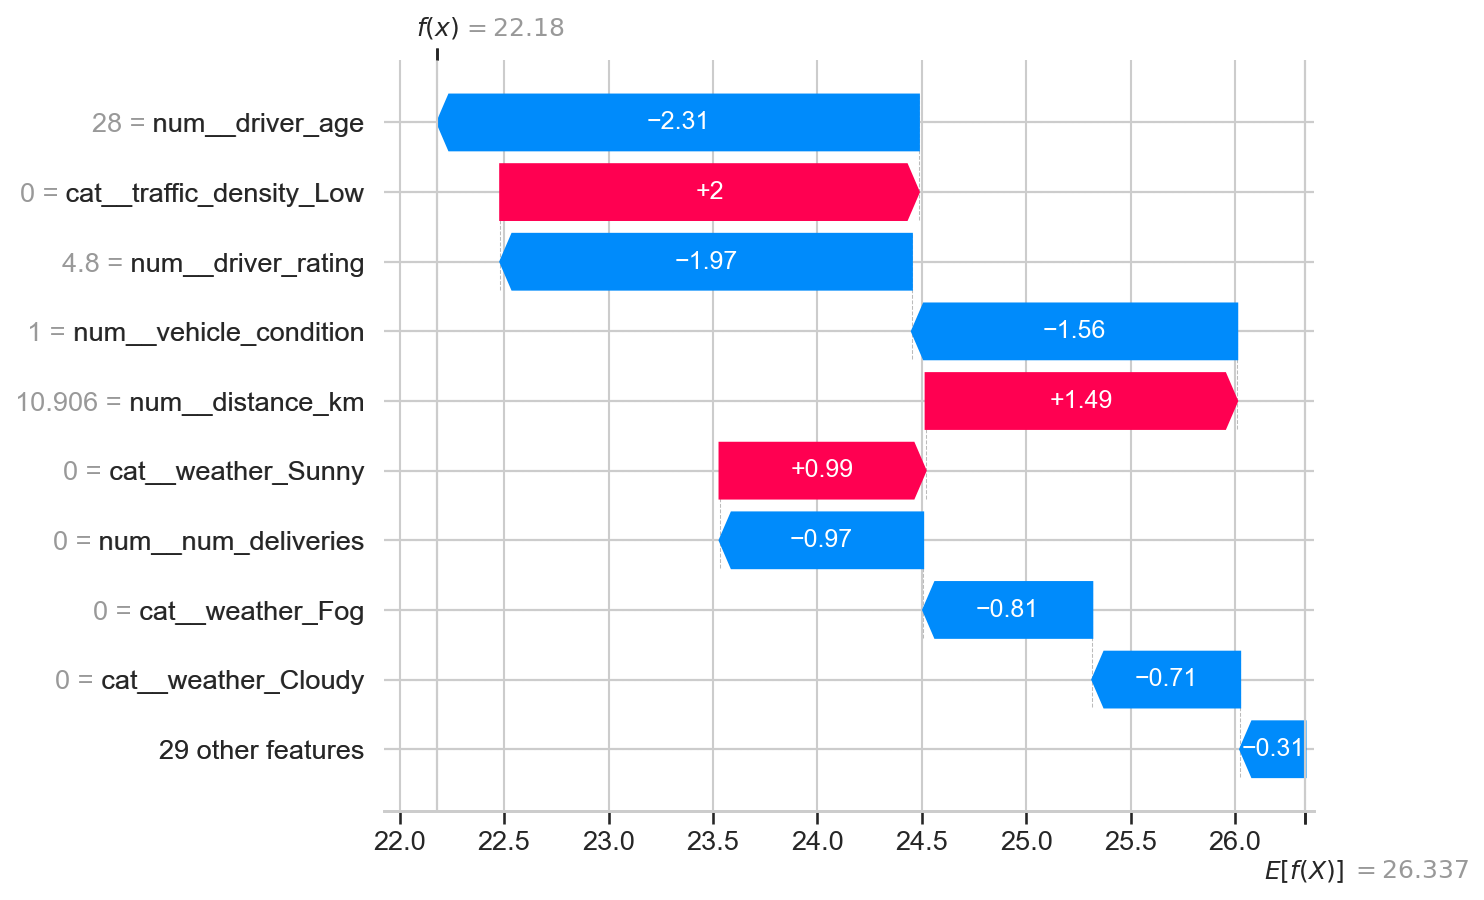

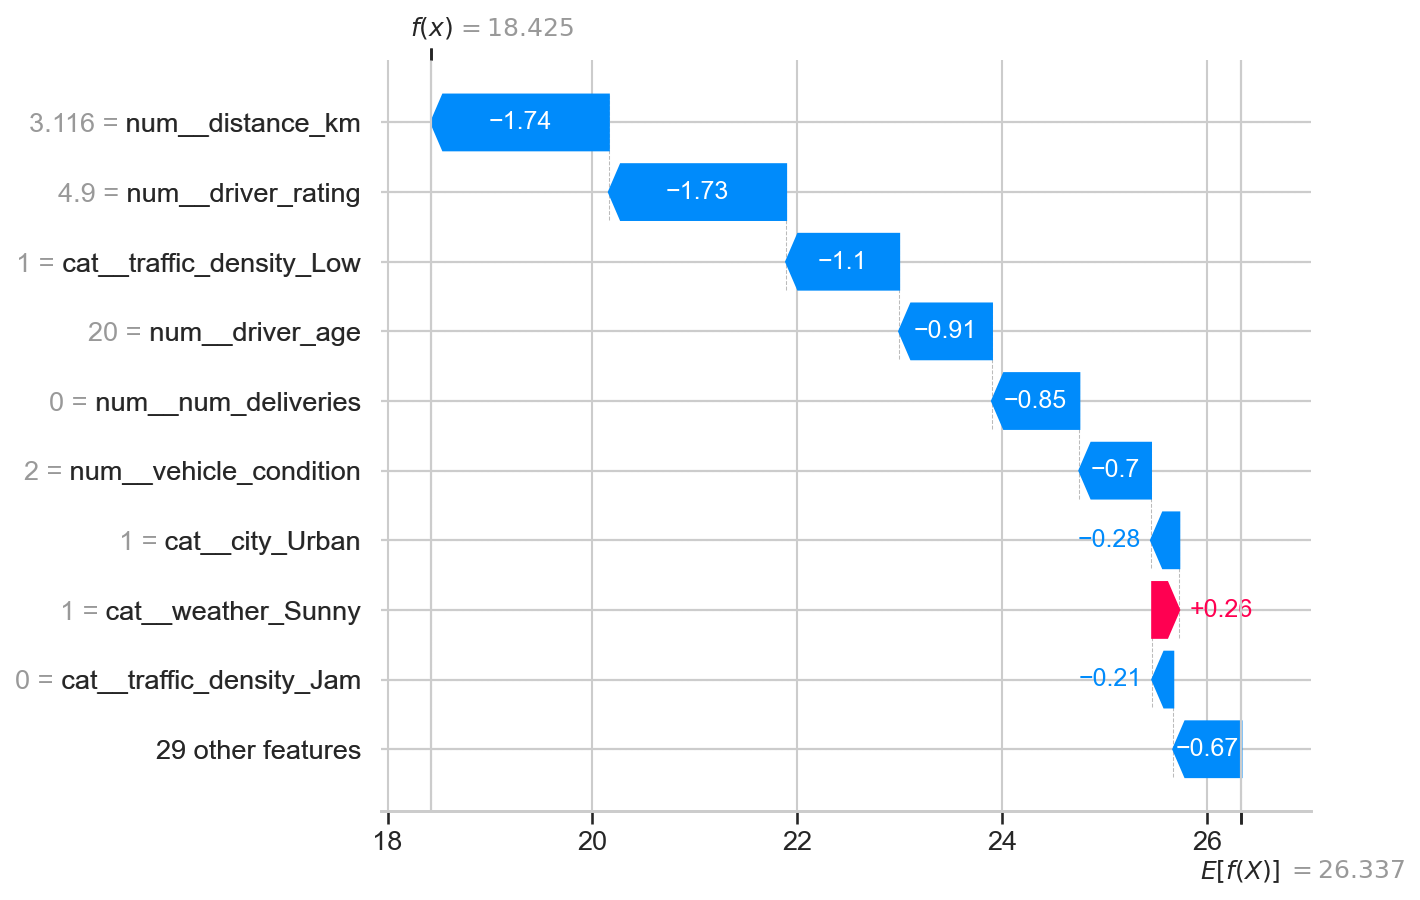

In [21]:
# =========================
# Explain Individual Predictions (Waterfall)
# =========================
sample_indices = [0, 3, 5]

for sample_idx in sample_indices:
    if sample_idx < len(X_val_shap_transformed):
        try:
            shap.plots.waterfall(shap_values[sample_idx], show=False)
            save_plot(f"shap_waterfall_{sample_idx}")
            plt.show()
        except Exception as e:
            print(f"Could not create waterfall plot for sample {sample_idx}: {e}")

In [22]:
# =========================
# Validation Analysis Table
# =========================
df_val = X_val.copy()
df_val["actual"] = y_val
df_val["predicted"] = val_preds
df_val["error"] = df_val["actual"] - df_val["predicted"]
df_val["abs_error"] = np.abs(df_val["error"])

print("\nValidation analysis preview:")
print(df_val.head())


Validation analysis preview:
       driver_age  driver_rating weather traffic_density  vehicle_condition  \
21697        31.0            4.8   Windy             Jam                  0   
6708         31.0            4.9  Cloudy             Low                  0   
8982         28.0            4.9  Stormy             Low                  1   
24225        28.0            4.8  Stormy          Medium                  1   
36600        35.0            4.9   Sunny             Low                  1   

      order_type vehicle_type  num_deliveries is_festival           city  \
21697     Drinks   motorcycle               1          No  Metropolitian   
6708      Drinks   motorcycle               0          No          Urban   
8982      Buffet   motorcycle               0          No          Urban   
24225     Drinks   motorcycle               0          No  Metropolitian   
36600     Drinks   motorcycle               0          No  Metropolitian   

       distance_km  order_hour  order_

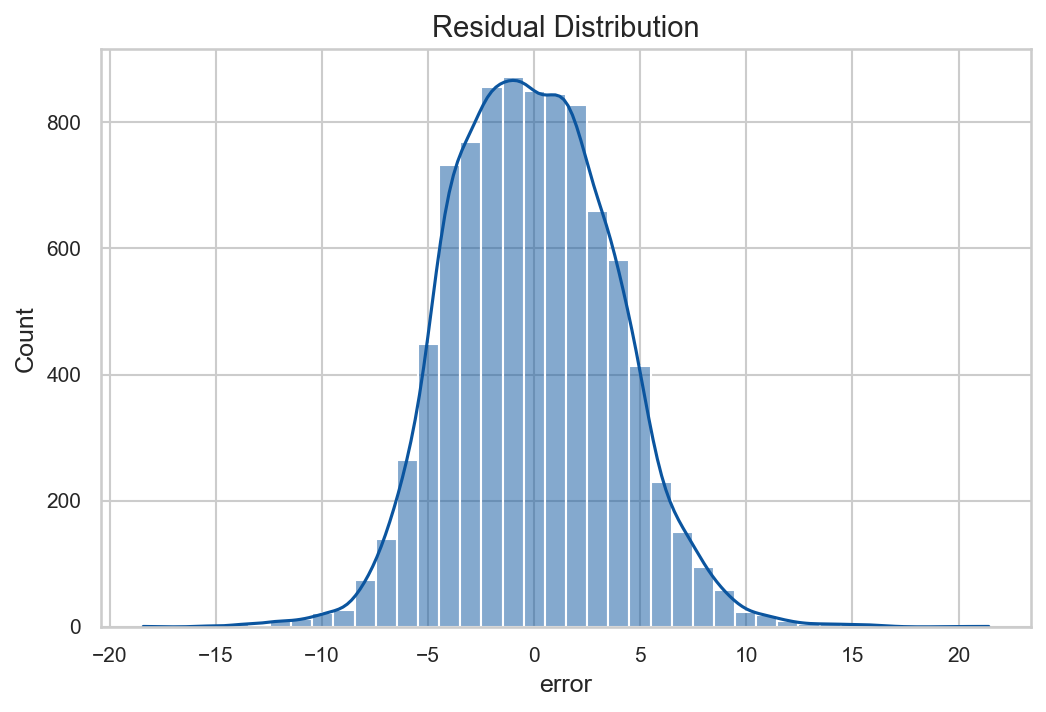

In [23]:
# =========================
# Residual Distribution
# =========================
plt.figure(figsize=(8, 5))
sns.histplot(df_val["error"], bins=40, kde=True)
plt.title("Residual Distribution")
save_plot("residuals")
plt.show()

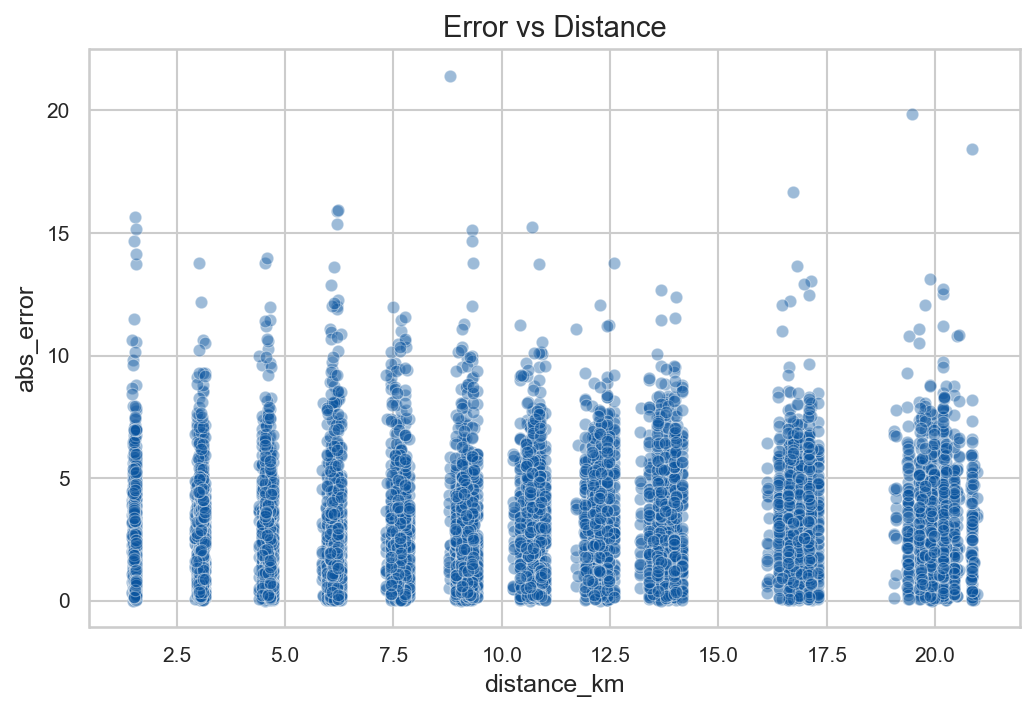

In [24]:
# =========================
# Error vs Distance
# =========================
if "distance_km" in df_val.columns:
    plt.figure(figsize=(8, 5))
    sns.scatterplot(data=df_val, x="distance_km", y="abs_error", alpha=0.4)
    plt.title("Error vs Distance")
    save_plot("error_distance")
    plt.show()

In [25]:
# =========================
# Near vs Far Delivery Error
# =========================
if "distance_km" in df_val.columns:
    median_distance = df_val["distance_km"].median()

    far_mae = df_val[df_val["distance_km"] >= median_distance]["abs_error"].mean()
    near_mae = df_val[df_val["distance_km"] < median_distance]["abs_error"].mean()

    print("\n=== Distance Fairness Check ===")
    print("Median distance:", median_distance)
    print("Far MAE:", far_mae)
    print("Near MAE:", near_mae)
    print("Difference:", abs(far_mae - near_mae))


=== Distance Fairness Check ===
Median distance: 9.192333207689474
Far MAE: 3.2774954028604215
Near MAE: 2.817806424061297
Difference: 0.4596889787991243


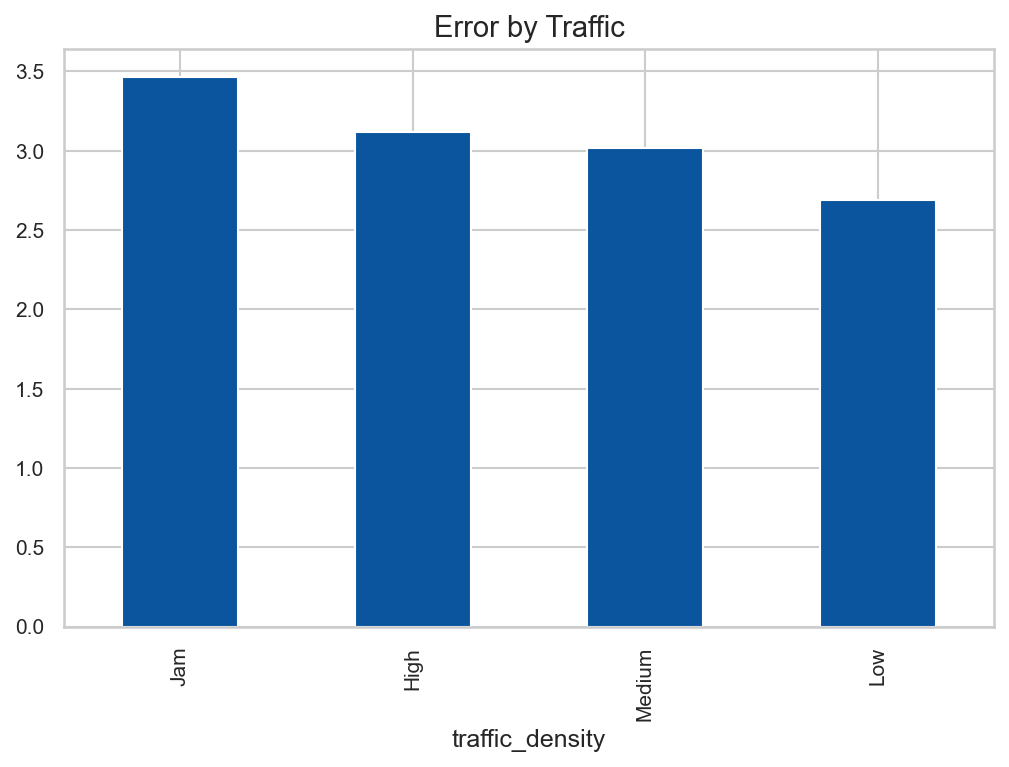


Highest Error Traffic Levels:
traffic_density
Jam       3.468317
High      3.115913
Medium    3.014790
Low       2.687688
Name: abs_error, dtype: float64


In [26]:
# =========================
# Error by Traffic
# =========================
if "traffic_density" in df_val.columns:
    traffic_bias = df_val.groupby("traffic_density")["abs_error"].mean().sort_values(ascending=False)

    plt.figure(figsize=(8, 5))
    traffic_bias.plot(kind="bar")
    plt.title("Error by Traffic")
    save_plot("bias_traffic")
    plt.show()

    print("\nHighest Error Traffic Levels:")
    print(traffic_bias)

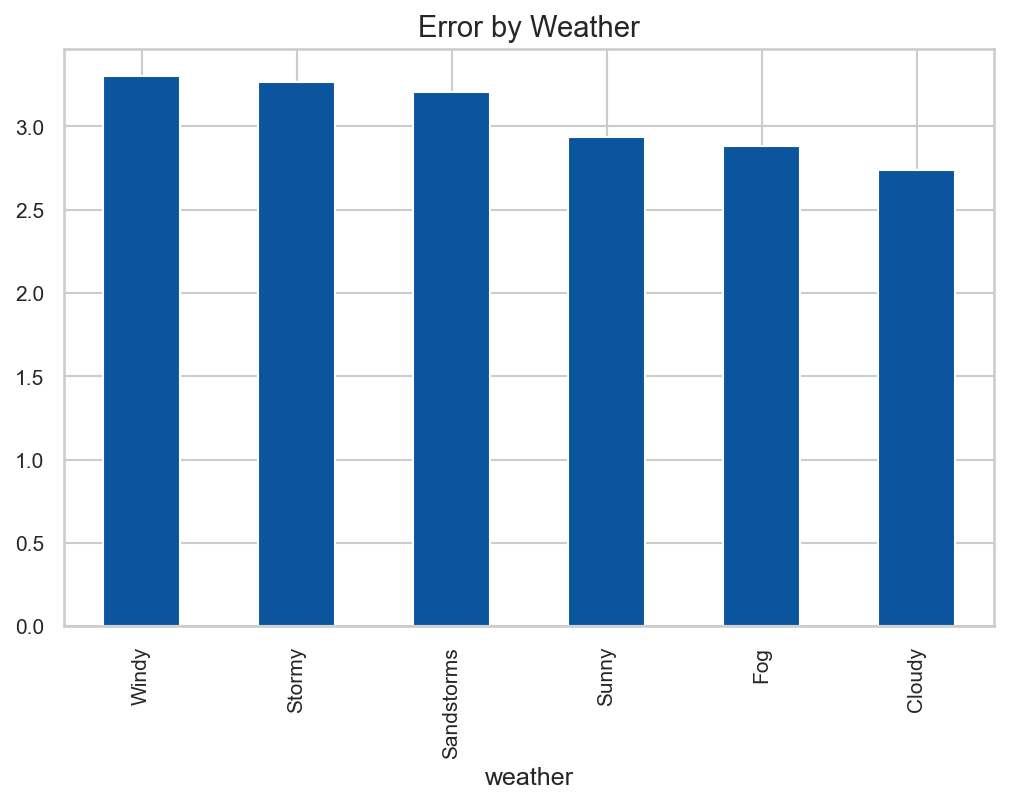


Highest Error Weather Conditions:
weather
Windy         3.301165
Stormy        3.264468
Sandstorms    3.203438
Sunny         2.935205
Fog           2.880572
Cloudy        2.735720
Name: abs_error, dtype: float64


In [27]:
# =========================
# Error by Weather
# =========================
if "weather" in df_val.columns:
    weather_bias = df_val.groupby("weather")["abs_error"].mean().sort_values(ascending=False)

    plt.figure(figsize=(8, 5))
    weather_bias.plot(kind="bar")
    plt.title("Error by Weather")
    save_plot("bias_weather")
    plt.show()

    print("\nHighest Error Weather Conditions:")
    print(weather_bias)

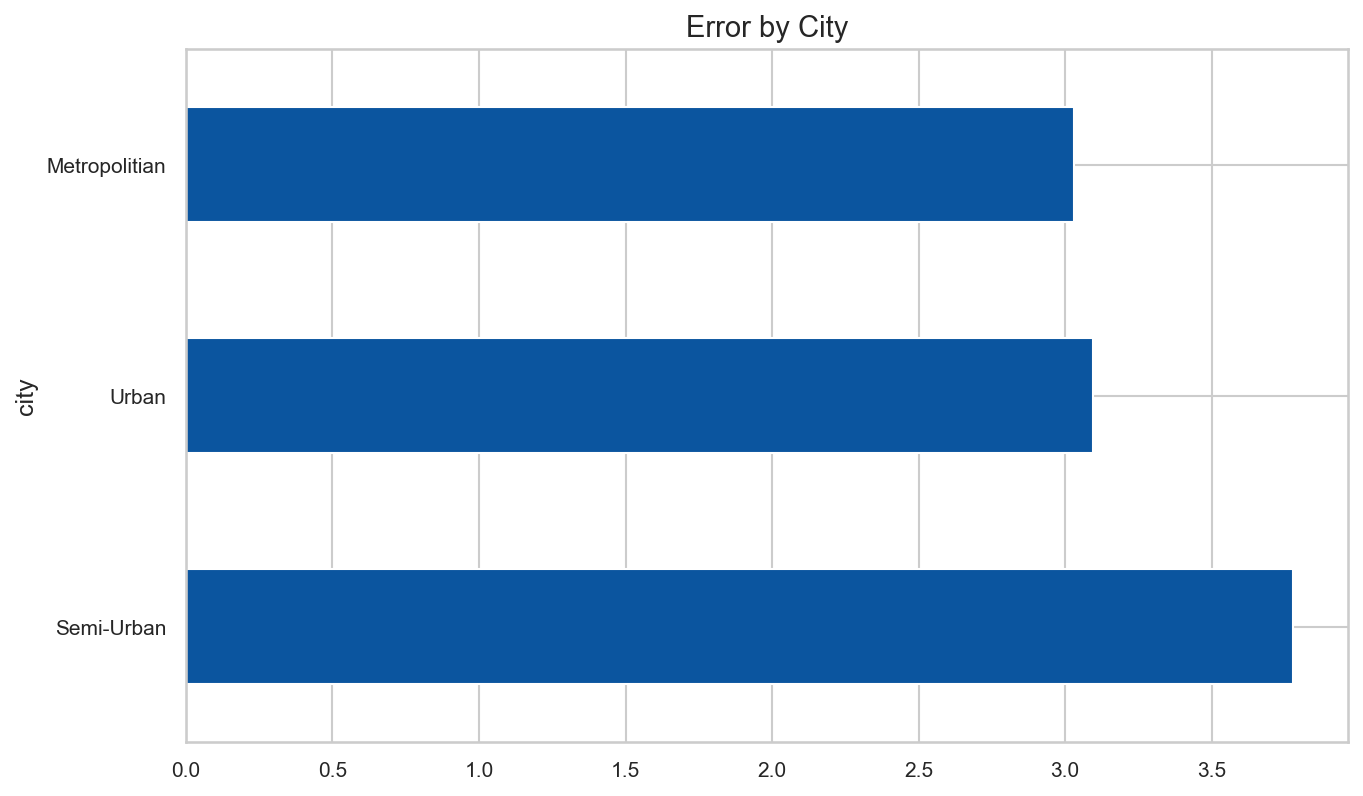


Highest Error Cities:
city
Semi-Urban       3.777102
Urban            3.095072
Metropolitian    3.031500
Name: abs_error, dtype: float64


In [28]:
# =========================
# Error by City
# =========================
if "city" in df_val.columns:
    city_bias = df_val.groupby("city")["abs_error"].mean().sort_values(ascending=False)

    plt.figure(figsize=(10, 6))
    city_bias.plot(kind="barh")
    plt.title("Error by City")
    save_plot("bias_city")
    plt.show()

    print("\nHighest Error Cities:")
    print(city_bias.head())

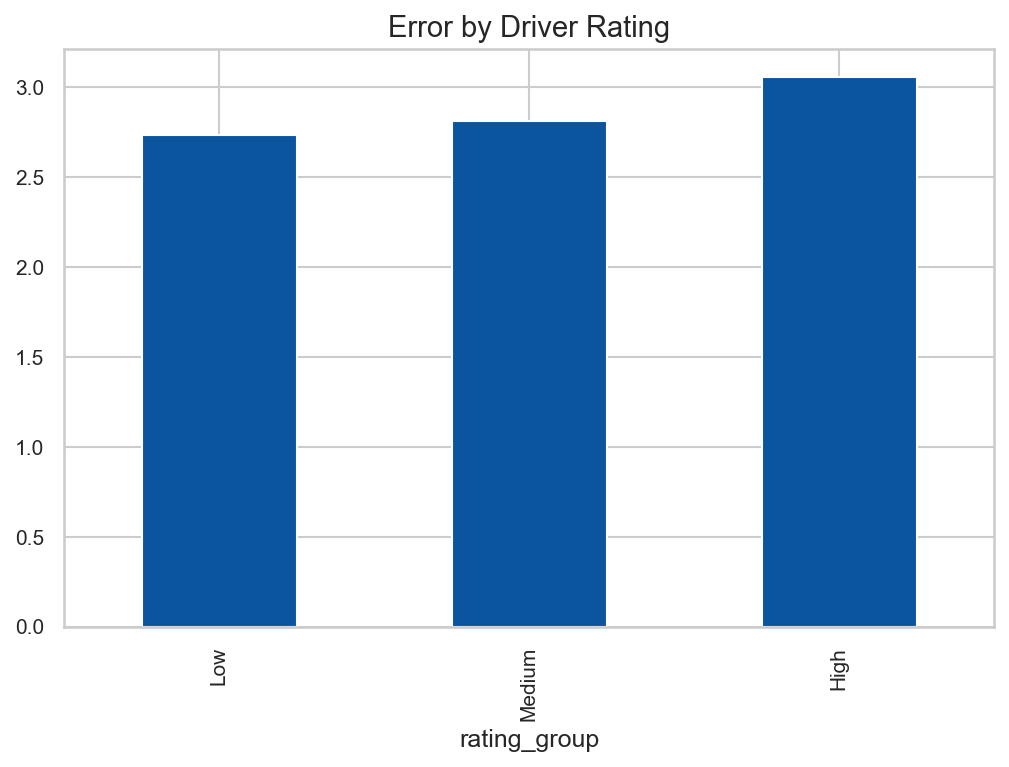


Error by Driver Rating Group:
rating_group
Low       2.734723
Medium    2.814538
High      3.061111
Name: abs_error, dtype: float64


In [29]:
# =========================
# Error by Driver Rating Group
# =========================
if "driver_rating" in df_val.columns:
    df_val["rating_group"] = pd.cut(
        df_val["driver_rating"],
        bins=[0, 3, 4, 5],
        labels=["Low", "Medium", "High"]
    )

    rating_bias = df_val.groupby("rating_group")["abs_error"].mean()

    plt.figure(figsize=(8, 5))
    rating_bias.plot(kind="bar")
    plt.title("Error by Driver Rating")
    save_plot("bias_rating")
    plt.show()

    print("\nError by Driver Rating Group:")
    print(rating_bias)


In [30]:
# =========================
# Proxy / Responsible AI Check
# =========================
# Approximate how much of model influence is driven by selected groups of variables.
# Adjust these lists depending on what you want to treat as "proxy" or sensitive-context features.
proxy_groups = {
    "location": [c for c in X_val_shap_transformed.columns if "city" in c.lower()],
    "traffic": [c for c in X_val_shap_transformed.columns if "traffic" in c.lower()],
    "weather": [c for c in X_val_shap_transformed.columns if "weather" in c.lower()],
    "distance": [c for c in X_val_shap_transformed.columns if "distance" in c.lower()],
}

total_shap = mean_shap.sum()

print("\n=== Proxy / Influence Breakdown ===")
for group_name, cols in proxy_groups.items():
    if len(cols) == 0:
        continue

    idxs = [list(X_val_shap_transformed.columns).index(c) for c in cols]
    group_pct = mean_shap[idxs].sum() / total_shap * 100
    print(f"{group_name.capitalize():10s}: {group_pct:6.2f}% ({len(cols)} features)")


=== Proxy / Influence Breakdown ===
Location  :   1.33% (3 features)
Traffic   :  20.93% (4 features)
Weather   :  14.88% (6 features)
Distance  :  13.16% (1 features)


In [31]:
# =========================
# Single Prediction Explanation Helper
# =========================
def explain_single_prediction(
    original_index=0,
    top_n=5,
    actual_series=None,
    predicted_array=None
):
    """
    Print a non-technical explanation of one prediction based on SHAP values.
    original_index should refer to position in X_val_shap_transformed / shap_values.
    """
    row_shap = shap_values[original_index]
    row_vals = pd.DataFrame({
        "feature": X_val_shap_transformed.columns,
        "shap_value": row_shap.values,
        "abs_shap": np.abs(row_shap.values)
    }).sort_values("abs_shap", ascending=False)

    top_feats = row_vals.head(top_n)

    print(f"\n=== Explanation for Sample {original_index} ===")

    if actual_series is not None and predicted_array is not None:
        idx = X_val_shap_transformed.index[original_index]
        print("Actual delivery time:", actual_series.loc[idx])
        print("Predicted delivery time:", predicted_array[list(X_val.index).index(idx)])

    print("\nTop contributing features:")
    print(top_feats[["feature", "shap_value"]])

    positives = top_feats[top_feats["shap_value"] > 0]
    negatives = top_feats[top_feats["shap_value"] < 0]

    explanation_parts = []

    if not positives.empty:
        pos_text = ", ".join(
            [f"{row.feature} (+{row.shap_value:.2f})" for row in positives.itertuples()]
        )
        explanation_parts.append(
            f"The prediction was pushed upward mainly by: {pos_text}."
        )

    if not negatives.empty:
        neg_text = ", ".join(
            [f"{row.feature} ({row.shap_value:.2f})" for row in negatives.itertuples()]
        )
        explanation_parts.append(
            f"The prediction was pushed downward mainly by: {neg_text}."
        )

    for part in explanation_parts:
        print(part)


# Example explanation
explain_single_prediction(
    original_index=5 if len(X_val_shap_transformed) > 5 else 0,
    top_n=5,
    actual_series=y_val,
    predicted_array=val_preds
)


=== Explanation for Sample 5 ===
Actual delivery time: 20
Predicted delivery time: 18.424937693628948

Top contributing features:
                     feature  shap_value
4           num__distance_km   -1.735496
1         num__driver_rating   -1.730546
16  cat__traffic_density_Low   -1.103541
0            num__driver_age   -0.906217
3        num__num_deliveries   -0.853019
The prediction was pushed downward mainly by: num__distance_km (-1.74), num__driver_rating (-1.73), cat__traffic_density_Low (-1.10), num__driver_age (-0.91), num__num_deliveries (-0.85).


In [32]:
# =========================
# Summary Outputs
# =========================
print("\n=== FINAL SUMMARY ===")
print("Best model:", metadata["best_model_name"])
print("Family:", metadata["best_model_family"])
print("Type:", metadata["best_model_type"])

if importance_df is not None:
    print("\nTop 5 Built-in Important Features:")
    print(importance_df.head(5))

print("\nTop 10 SHAP Features:")
print(shap_importance.head(10))


=== FINAL SUMMARY ===
Best model: FLAML AutoML
Family: automl_flaml
Type: sklearn

Top 5 Built-in Important Features:
                     feature  importance
1         num__driver_rating    0.197137
16  cat__traffic_density_Low    0.111132
3        num__num_deliveries    0.105657
4           num__distance_km    0.103002
0            num__driver_age    0.097462

Top 10 SHAP Features:
                     feature  mean_abs_shap
16  cat__traffic_density_Low       2.420890
1         num__driver_rating       2.412203
0            num__driver_age       2.389443
4           num__distance_km       2.144566
2     num__vehicle_condition       1.849870
12        cat__weather_Sunny       0.979935
3        num__num_deliveries       0.774696
9           cat__weather_Fog       0.623236
15  cat__traffic_density_Jam       0.615645
8        cat__weather_Cloudy       0.565101


In [33]:
if "distance_km" in df_val.columns:
    print("\nDistance-based error summary complete.")

if "traffic_density" in df_val.columns:
    print("Traffic-based error analysis complete.")

if "weather" in df_val.columns:
    print("Weather-based error analysis complete.")

if "city" in df_val.columns:
    print("City-based error analysis complete.")

if "driver_rating" in df_val.columns:
    print("Driver-rating-based error analysis complete.")

print("\nFigures saved to:", FIG_DIR)
print("\nAvailable transformed feature names:")
print(list(feature_names))


Distance-based error summary complete.
Traffic-based error analysis complete.
Weather-based error analysis complete.
City-based error analysis complete.
Driver-rating-based error analysis complete.

Figures saved to: ../reports/figures

Available transformed feature names:
['num__driver_age', 'num__driver_rating', 'num__vehicle_condition', 'num__num_deliveries', 'num__distance_km', 'num__order_hour', 'num__is_weekend', 'num__is_peak_hour', 'cat__weather_Cloudy', 'cat__weather_Fog', 'cat__weather_Sandstorms', 'cat__weather_Stormy', 'cat__weather_Sunny', 'cat__weather_Windy', 'cat__traffic_density_High', 'cat__traffic_density_Jam', 'cat__traffic_density_Low', 'cat__traffic_density_Medium', 'cat__order_type_Buffet', 'cat__order_type_Drinks', 'cat__order_type_Meal', 'cat__order_type_Snack', 'cat__vehicle_type_bicycle', 'cat__vehicle_type_electric_scooter', 'cat__vehicle_type_motorcycle', 'cat__vehicle_type_scooter', 'cat__is_festival_No', 'cat__is_festival_Yes', 'cat__city_Metropolitian',